# Kurtogram Demo

This notebook shows how to use `kurtogram_utils` to:

1. Load a vibration CSV file
2. Compute the spectral kurtosis curve
3. Pick the most impulsive frequency band
4. Band‑pass filter the signal
5. Extract and plot the Hilbert envelope


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band, plot_sk
from brf_lightning.data.bearing.utils import load_vibration_data

plt.rcParams['figure.dpi'] = 110


## 1. Load a CSV vibration file

In [5]:
# Update this path to your dataset
csv_path = Path('data/bearing_thl_v1/fAII20.csv')

df, fs = load_vibration_data(csv_path)
x = df['sensor_bearing'].to_numpy(dtype=np.float32)
print(f"Loaded {len(x):,d} samples @ {fs} Hz")

Loaded 4,861,952 samples @ 8192.0 Hz


## 2. Compute Spectral Kurtosis

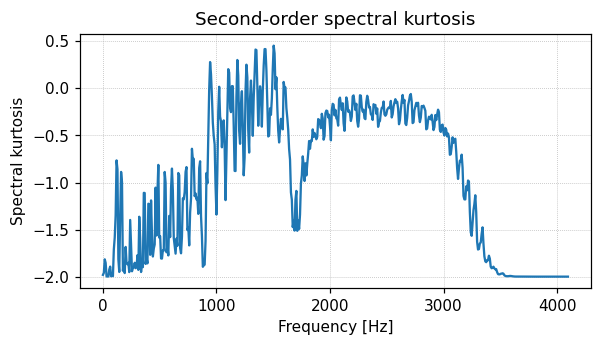

In [6]:
f, sk = spectral_kurtosis(x, fs, nperseg=1024)
_ = plot_sk(f, sk)

## 3. Pick the band with maximum SK

In [ ]:
f_lo, f_hi = max_sk_band(f, sk, bandwidth=2000)
print(f"Selected band: {f_lo:.0f}-{f_hi:.0f} Hz")

Selected band: 1016–3008 Hz


## 4. Band‑pass filter and envelope extraction

In [8]:
nyq = 0.5 * fs
sos = sig.butter(4, [f_lo/nyq, f_hi/nyq], btype='bandpass', output='sos')
xf = sig.sosfiltfilt(sos, x)

# Hilbert envelope
env = np.abs(sig.hilbert(xf))

## 5. Visualise raw, band‑passed, and envelope

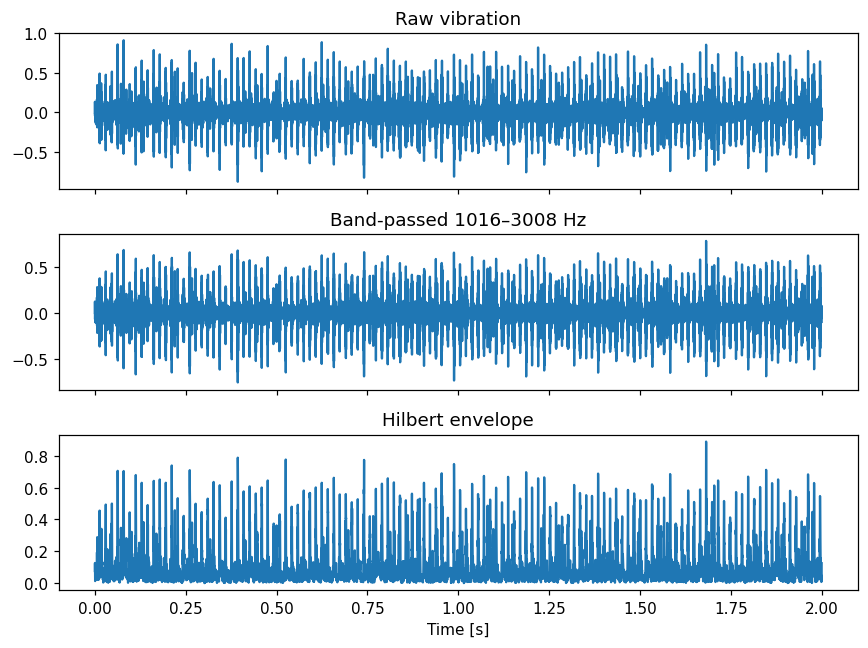

In [ ]:
t = np.arange(len(x)) / fs
seg = slice(0, int(2*fs))  # first 2 seconds for illustration

fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axs[0].plot(t[seg], x[seg]); axs[0].set_title('Raw vibration')
axs[1].plot(t[seg], xf[seg]); axs[1].set_title(f'Band-passed {f_lo:.0f}-{f_hi:.0f} Hz')
axs[2].plot(t[seg], env[seg]); axs[2].set_title('Hilbert envelope')
axs[2].set_xlabel('Time [s]')
plt.tight_layout()

In [11]:
df["trig"]

0          0
1          0
2          0
3          0
4          0
          ..
4861947    0
4861948    0
4861949    0
4861950    0
4861951    0
Name: trig, Length: 4861952, dtype: int64